## calculer corrélation entre (total_conv_a_output_tokens − total_conv_b_output_tokens) et (chosen_model_name == model_a_name). 

In [120]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

base_dir = Path.cwd()
file_path_votes = base_dir.parent / "data" / "comparia-votes" / "votes_samples.jsonl"
df_votes = pd.read_json(file_path_votes, lines=True)
file_path_conversations = base_dir.parent / "data" / "comparia-conversations" / "conversations_samples.jsonl"
df_conversations = pd.read_json(file_path_conversations, lines=True)


In [121]:
print(df_votes.columns)

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name',
       'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a',
       'conversation_b', 'conv_turns', 'selected_category',
       'is_unedited_prompt', 'conversation_pair_id', 'session_hash',
       'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a',
       'conv_useful_b', 'conv_creative_a', 'conv_creative_b',
       'conv_clear_formatting_a', 'conv_clear_formatting_b',
       'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a',
       'conv_superficial_b', 'conv_instructions_not_followed_a',
       'conv_instructions_not_followed_b', 'system_prompt_b',
       'system_prompt_a', 'conv_complete_a', 'conv_complete_b'],
      dtype='str')


In [122]:
df_votes.iloc[0]

id                                                                               4400
timestamp                                                  2024-10-14 12:35:18.238000
model_a_name                                                            gemma-2-9b-it
model_b_name                                                    phi-3.5-mini-instruct
model_pair_name                                [gemma-2-9b-it, phi-3.5-mini-instruct]
chosen_model_name                                                       gemma-2-9b-it
opening_msg                         Comment rédiger une attestation d'hébergement ...
both_equal                                                                        NaN
conversation_a                      [{'role': 'user', 'content': 'Comment rédiger ...
conversation_b                      [{'role': 'user', 'content': 'Comment rédiger ...
conv_turns                                                                          1
selected_category                                     

In [123]:
df_votes.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,conv_turns,selected_category,is_unedited_prompt,conversation_pair_id,session_hash,visitor_id,conv_comments_a,conv_comments_b,conv_useful_a,conv_useful_b,conv_creative_a,conv_creative_b,conv_clear_formatting_a,conv_clear_formatting_b,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,4400,2024-10-14 12:35:18.238,gemma-2-9b-it,phi-3.5-mini-instruct,"[gemma-2-9b-it, phi-3.5-mini-instruct]",gemma-2-9b-it,Comment rédiger une attestation d'hébergement ...,NaN,"[{'role': 'user', 'content': 'Comment rédiger ...","[{'role': 'user', 'content': 'Comment rédiger ...",1,administrative,True,cd6f1b6fe7914ab59e5714a340a6c75c-e0d4241d798e4...,eefjajqsjjj,c1fc1f428e2a654520736b34a33b1204,,,False,False,False,False,True,False,False,False,False,True,False,False,,,True,True
1,109754,2025-10-19 11:48:33.355,command-a,glm-4.6,"[command-a, glm-4.6]",NaN,Faites moi un script python pour jouer à Mario...,1.0,"[{'role': 'user', 'content': 'Faites moi un sc...","[{'role': 'user', 'content': 'Faites moi un sc...",1,NaN,False,e1edd24739824a8a883a63c29af1c360-c5551a40bfa64...,2ze917ia8cv,99c92d64850a82de6b79a1df195cfb21,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False
2,129388,2025-12-01 12:46:14.799,qwen3-max-2025-09-23,gpt-5-nano,"[gpt-5-nano, qwen3-max-2025-09-23]",NaN,QUEL EST VOTRE IMPACT SUR LENVIRONEMENT,1.0,"[{'role': 'user', 'content': 'QUEL EST VOTRE I...","[{'role': 'user', 'content': 'QUEL EST VOTRE I...",1,NaN,False,87392847c2844ac0bc592a2091685cf6-bcb25a54f6d04...,zd20d86o0nn,98fe43ad844a15d7f00af754e45ed81e,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False
3,144518,2026-01-09 09:48:49.521,deepseek-r1-0528,glm-4.7,"[deepseek-r1-0528, glm-4.7]",NaN,connais tu Malone Courtecuisse,1.0,"[{'role': 'user', 'content': 'connais tu Malon...","[{'role': 'user', 'content': 'connais tu Malon...",1,NaN,False,599de720bd804301b141a39fb9ee9b11-0cf07a983f754...,14fv0eqe917d,fc56866e083476414e83d6f9e3c7f278,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False
4,171722,2026-03-10 13:59:52.684,gemini-3.1-flash-lite-preview,EuroLLM-22B-Instruct-2512,"[EuroLLM-22B-Instruct-2512, gemini-3.1-flash-l...",EuroLLM-22B-Instruct-2512,quel sera le prochain président de la républiq...,0.0,"[{'role': 'user', 'content': 'quel sera le pro...","[{'role': 'user', 'content': 'quel sera le pro...",1,NaN,False,47be83af3bab4ab28f134368f708ec59-0f9b513ce1da4...,34162365-e7f7-4e0b-bcb4-68b35e79ac1d,2d2b8037ac25d1b5b77090ccdd92e1c9,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False


In [124]:
df_conversations.head()

,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,session_hash,visitor_id,model_pair_name,opening_msg,system_prompt_a,system_prompt_b,mode,custom_models_selection,short_summary,keywords,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
0,1165219,2025-12-05 09:04:27.588,gemma-3-12b,mistral-small-2506,"[{'role': 'user', 'content': 'ecris moi un tex...","[{'role': 'user', 'content': 'ecris moi un tex...",1,b0dbd35a9c3c463589bc4ddfce97afec-487e7c50be234...,b0dbd35a9c3c463589bc4ddfce97afec,487e7c50be234c52b4c470c6caae315a,qt47yf5s9u,052301ae9bf78c0f229235dfa25509c5,"{gemma-3-12b,mistral-small-2506}",ecris moi un texte court sur l'ia,NaN,NaN,custom,None,The text discusses the transformative power of...,"[Artificial Intelligence, algorithms, neural n...",[Natural Science & Formal Science & Technology],[fr],185,177,12.0,24.0,12.0,24.0,0.000017,0.000019
1,154961,2025-02-20 08:09:44.384,gemma-2-9b-it,llama-3.1-405b,"[{'role': 'user', 'content': 'a quoi peut etre...","[{'role': 'user', 'content': 'a quoi peut etre...",1,6ff37587250e4ee5882c24cc74ec2ba7-9131ebe29e614...,6ff37587250e4ee5882c24cc74ec2ba7,9131ebe29e6145b9aae9513ccc60d96d,cvck22muqm9,fa7e51fb95eddf1336a6c5ee0e7f220f,"{gemma-2-9b-it,llama-3.1-405b}",a quoi peut etre dut une panne d’éclairage int...,,,random,None,The user asks what could cause an interior lig...,"[Jeep Renegade, éclairage intérieur, panne, am...",[Natural Science & Formal Science & Technology],[fr],550,465,9.0,405.0,9.0,405.0,0.000050,0.004247
2,945246,2025-10-10 12:12:22.470,llama-maverick,magistral-medium,"[{'role': 'user', 'content': 'a quoi sert comp...","[{'role': 'user', 'content': 'a quoi sert comp...",8,759af04e048a49b49b148762d8b5d675-fdccd0b774434...,759af04e048a49b49b148762d8b5d675,fdccd0b7744345b29206b1a665f522fc,dm6fi8w7jbh,bb89771efcf241c45b92fef4284b6b85,"{llama-maverick,magistral-medium}",a quoi sert compar ia,NaN,NaN,random,None,"The conversations discuss comparing AI models,...","[artificial intelligence, dropshipping, site c...",[Natural Science & Formal Science & Technology...,[fr],4522,4773,400.0,123.0,17.0,123.0,0.007240,0.004366
3,1396163,2026-02-03 23:49:25.196,glm-4.6,claude-4-5-sonnet,"[{'role': 'user', 'content': 'from carte impor...","[{'role': 'user', 'content': 'from carte impor...",0,86895dab64c4464b8a20ce8eb32b3b1a-46d72e9539a14...,86895dab64c4464b8a20ce8eb32b3b1a,46d72e9539a14e7ba974f0d514c0bfff,18h5gsqgsna,39ba563af6dfb0393c2a36732a615de2,"{claude-4-5-sonnet,glm-4.6}",from carte import Carte\nfrom joueur import Jo...,NaN,NaN,random,None,This code creates a game using the Pygame libr...,"[pygame, carte, joueur, creature, ecran, jeu]",[Natural Science & Formal Science & Technology...,[fr],0,0,357.0,440.0,32.0,137.0,0.000000,0.000000
4,9268,2024-11-22 14:39:11.162,phi-3.5-mini-instruct,qwen2.5-7b-instruct,"[{'role': 'user', 'content': 'peut tu faire de...","[{'role': 'user', 'content': 'peut tu faire de...",5,684fe703b47a48768e8534a3c2d1155f-0b05d69f2f5e4...,684fe703b47a48768e8534a3c2d1155f,0b05d69f2f5e42f0bd3250d500da0ae8,av5w618xn7n,eba437b0f1c31628e71b88d59c7356ce,"phi-3.5-mini-instruct,qwen2.5-7b-instruct",peut tu faire des recherches sur internet ou a...,,,NaN,None,"The user is comparing two AI models, Phi (Micr...","[AI models, Phi, Qwen, DTO, Lombok, Java, immu...",[Natural Science & Formal Science & Technology...,[fr],1350,1251,3.0,7.0,3.0,7.0,0.000112,0.000110


In [125]:
df_conversations.columns

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'conversation_a',
       'conversation_b', 'conv_turns', 'conversation_pair_id', 'conv_a_id',
       'conv_b_id', 'session_hash', 'visitor_id', 'model_pair_name',
       'opening_msg', 'system_prompt_a', 'system_prompt_b', 'mode',
       'custom_models_selection', 'short_summary', 'keywords', 'categories',
       'languages', 'total_conv_a_output_tokens', 'total_conv_b_output_tokens',
       'model_a_total_params', 'model_b_total_params', 'model_a_active_params',
       'model_b_active_params', 'total_conv_a_kwh', 'total_conv_b_kwh'],
      dtype='str')

On voit que l'on a le modèle choisi dans comparia-votes, et les tokens de sortie dans comparia-conversations. Il faut faire le lien entre les deux datasets pour calculer la corrélation demandée.

regardons si on peut les merge par conversation_pair_id, qui est présent dans les deux datasets.

In [126]:
df_votes["conversation_pair_id"].unique()

<ArrowStringArray>
['cd6f1b6fe7914ab59e5714a340a6c75c-e0d4241d798e45ef9cde78a50e11b21b',
 'e1edd24739824a8a883a63c29af1c360-c5551a40bfa64ddcabb28c729564bd58',
 '87392847c2844ac0bc592a2091685cf6-bcb25a54f6d04a339df0697d10c80e0b',
 '599de720bd804301b141a39fb9ee9b11-0cf07a983f7549e39b996176a6b47de8',
 '47be83af3bab4ab28f134368f708ec59-0f9b513ce1da46cfb12f5522fdd91ad9',
 '83419d6fa5c649bea31daf5b2ca1e0ff-afa0f956ca1e46c080f284c2e5dd971a',
 '829ce9f88fc74cf68dc1edef17dfe4fe-1e0f9aed3e9649f8b5a9a7fb95a55648',
 'cc9aa52d2ac34812904bf93021ee9da0-febd6a2dbcff4d26a01a07abd5b98c9a',
 '491a01016f2e40a9b8b1b55fa14bd6ac-b5e9089d55534623b64ee369c18e375f',
 '531566e10a5148dba6848f277a990799-1d120a7e598a4e2b81edf62e7a45f573',
 ...
 '831faae9a0004b7591d6d0100280ac3d-201f72d8a97d4c76be2a3a999a6e3da9',
 '4e8816db5d8d4e769f08290760bbe1df-5cdad78495814043b5b5604aee2b1a7b',
 'bbec8882753444409a6151b2c013660f-09b82a0ddc2940219abb72ac286d7fca',
 '652c9e90fa64422dae2883707ef0be1f-90f7bff7d4904e76aed32c0ce40682c

In [127]:
df_conversations["conversation_pair_id"].unique()

<ArrowStringArray>
['b0dbd35a9c3c463589bc4ddfce97afec-487e7c50be234c52b4c470c6caae315a',
 '6ff37587250e4ee5882c24cc74ec2ba7-9131ebe29e6145b9aae9513ccc60d96d',
 '759af04e048a49b49b148762d8b5d675-fdccd0b7744345b29206b1a665f522fc',
 '86895dab64c4464b8a20ce8eb32b3b1a-46d72e9539a14e7ba974f0d514c0bfff',
 '684fe703b47a48768e8534a3c2d1155f-0b05d69f2f5e42f0bd3250d500da0ae8',
 '434f6e306b43457ba0aef9f30ba91d31-5a6e0df3060d4082b2f97f8a9cd534b3',
 '4fa4056b658c455280387351b61bb18c-b6ecaa04f7c94563a00df245bc2497ab',
 '64c3566763314591a2ad074c48c085e3-00efddc845a24e25bfeaf24657266662',
 '7e88de2f500543bba92ee78cf14250a3-a1bce9aacb1a425fadb0524d3a934e66',
 '9675becaf5364420a65a3793e12584af-95df971ddb0d4f2aa42ad18ac730b572',
 ...
 'dc81e6008301421d8801bcbf9ae84461-a849dcc9a53749a78973a80a3b3e8393',
 'd570dd8a01d14ecc8c092b554a91ea96-c83d85001c1b4b1cb2aa005bcbf55353',
 '0678ebf4e6324062bdf82b57d94c66e5-ffef3d7d3c5b4272a32047ac919e1747',
 '247836fa74984316b977757c9a2c66bb-141f3c22f94840fd833704e057fdf25

In [128]:
intersection = set(df_votes["conversation_pair_id"]).intersection(set(df_conversations["conversation_pair_id"]))
print(f"Number of unique conversation_pair_id in df_votes: {len(df_votes['conversation_pair_id'].unique())}")
print(f"Number of unique conversation_pair_id in df_conversations: {len(df_conversations['conversation_pair_id'].unique())}")
print(f"Number of unique conversation_pair_id in the intersection: {len(intersection)}")

Number of unique conversation_pair_id in df_votes: 996
Number of unique conversation_pair_id in df_conversations: 1000
Number of unique conversation_pair_id in the intersection: 3


In [129]:
for conversation_pair_id in intersection:
    votes_subset = df_votes[df_votes["conversation_pair_id"] == conversation_pair_id]
    conversations_subset = df_conversations[df_conversations["conversation_pair_id"] == conversation_pair_id]
    print(f"Conversation Pair ID: {conversation_pair_id}")
    print("Votes Subset:")
    display(votes_subset)
    print("Conversations Subset:")
    display(conversations_subset)
    print("\n")

Conversation Pair ID: caab3fcb0a9e4065bbe52cbce049cd20-d69605ea309c4892a86459362c5e37ca
Votes Subset:


,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,conv_turns,selected_category,is_unedited_prompt,conversation_pair_id,session_hash,visitor_id,conv_comments_a,conv_comments_b,conv_useful_a,conv_useful_b,conv_creative_a,conv_creative_b,conv_clear_formatting_a,conv_clear_formatting_b,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
642,125171,2025-11-23 19:59:51.307,gemma-3-4b,magistral-medium,"[gemma-3-4b, magistral-medium]",NaN,Est-ce que le sang d'un polype uterin peut irr...,1.0,"[{'role': 'user', 'content': 'Est-ce que le sa...","[{'role': 'user', 'content': 'Est-ce que le sa...",4,NaN,False,caab3fcb0a9e4065bbe52cbce049cd20-d69605ea309c4...,t1b50giu789,00cce823232d7e4af19b6d3a6502f7a4,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False


Conversations Subset:


,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,session_hash,visitor_id,model_pair_name,opening_msg,system_prompt_a,system_prompt_b,mode,custom_models_selection,short_summary,keywords,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
461,1104915,2025-11-23 19:50:30.345,gemma-3-4b,magistral-medium,"[{'role': 'user', 'content': 'Est-ce que le sa...","[{'role': 'user', 'content': 'Est-ce que le sa...",4,caab3fcb0a9e4065bbe52cbce049cd20-d69605ea309c4...,caab3fcb0a9e4065bbe52cbce049cd20,d69605ea309c4892a86459362c5e37ca,t1b50giu789,00cce823232d7e4af19b6d3a6502f7a4,"{gemma-3-4b,magistral-medium}",Est-ce que le sang d'un polype uterin peut irr...,NaN,NaN,random,None,A user is experiencing discomfort and bleeding...,"[polype uterin, vagin, irritation, symptoms, b...",[Health & Wellness & Medicine],[fr],3164,2659,4.0,123.0,4.0,123.0,0.000267,0.002432




Conversation Pair ID: fc7b4fc5252643bd947853e00b3eb495-e26dc76388ab445a97e624a3b667c757
Votes Subset:


...

,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,session_hash,visitor_id,model_pair_name,opening_msg,system_prompt_a,system_prompt_b,mode,custom_models_selection,short_summary,keywords,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
511,691119,2025-07-04 12:53:23.261,qwen2.5-coder-32b-instruct,llama-3.1-8b,"[{'role': 'user', 'content': 'Qui a théorisé l...","[{'role': 'user', 'content': 'Qui a théorisé l...",1,fc7b4fc5252643bd947853e00b3eb495-e26dc76388ab4...,fc7b4fc5252643bd947853e00b3eb495,e26dc76388ab445a97e624a3b667c757,xx2jxpbhpa,6e36ade25aa3544a7832dd26356d8b31,"{llama-3.1-8b,qwen2.5-coder-32b-instruct}",Qui a théorisé la relativité restreinte ?,NaN,NaN,random,None,The conversation discusses the theory of speci...,"[relativité restreinte, Albert Einstein, physi...",[Natural Science & Formal Science & Technology...,[fr],159,84,NaN,8.0,NaN,8.0,0.0,0.000007




Conversation Pair ID: cec891f9fe664a39aae97e05d6cf47ee-fb021ac9f5d94150818acfb5e5f2e6c9
Votes Subset:


,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,conv_turns,selected_category,is_unedited_prompt,conversation_pair_id,session_hash,visitor_id,conv_comments_a,conv_comments_b,conv_useful_a,conv_useful_b,conv_creative_a,conv_creative_b,conv_clear_formatting_a,conv_clear_formatting_b,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
83,170891,2026-03-09 13:17:31.784,claude-4-6-sonnet,EuroLLM-22B-Instruct-2512,"[EuroLLM-22B-Instruct-2512, claude-4-6-sonnet]",EuroLLM-22B-Instruct-2512,Combien de temps va durer la guerre en Iran?,0.0,"[{'role': 'user', 'content': 'Combien de temps...","[{'role': 'user', 'content': 'Combien de temps...",1,NaN,False,cec891f9fe664a39aae97e05d6cf47ee-fb021ac9f5d94...,a676dbf5-a30a-4da2-a139-00d511861891,ae1a2c464a2895f309048be9d08863e8,,,False,True,False,False,False,True,True,False,False,False,False,False,NaN,NaN,False,False


Conversations Subset:


,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,session_hash,visitor_id,model_pair_name,opening_msg,system_prompt_a,system_prompt_b,mode,custom_models_selection,short_summary,keywords,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
90,1569363,2026-03-09 13:13:37.086,claude-4-6-sonnet,EuroLLM-22B-Instruct-2512,"[{'role': 'user', 'content': 'Combien de temps...","[{'role': 'user', 'content': 'Combien de temps...",1,cec891f9fe664a39aae97e05d6cf47ee-fb021ac9f5d94...,cec891f9fe664a39aae97e05d6cf47ee,fb021ac9f5d94150818acfb5e5f2e6c9,a676dbf5-a30a-4da2-a139-00d511861891,ae1a2c464a2895f309048be9d08863e8,"{EuroLLM-22B-Instruct-2512,claude-4-6-sonnet}",Combien de temps va durer la guerre en Iran?,NaN,NaN,random,[],The user inquired about the duration of a conf...,"[conflict, Iran, geopolitics, tensions, region...",[Politics & Government],[fr],224,370,440.0,22.0,137.0,22.0,0.000881,0.000039


In [130]:
intersection_opening_msg = set(df_votes[df_votes["conversation_pair_id"].isin(intersection)]["opening_msg"]).intersection(set(df_conversations[df_conversations["conversation_pair_id"].isin(intersection)]["opening_msg"]))
print(f"Number of unique opening_msg in the intersection: {len(intersection_opening_msg)}")

Number of unique opening_msg in the intersection: 3


IL ya trop peu d'intersection pour faire une corrélation significative, donc en longueur je vais utiliser la taille en nombre de caractère de la réponse

In [131]:
#vérifier que les conversations on toujours la même forme
for i in range(df_votes.shape[0]):
    len_a=len(df_votes['conversation_a'][i])
    len_b=len(df_votes['conversation_b'][i])
    if len_a!=2:
        print(f"conversation_a at index {i} has length {len_a}")
    if len_b!=2:
        print(f"conversation_b at index {i} has length {len_b}")


conversation_a at index 5 has length 8
conversation_b at index 5 has length 8
conversation_a at index 14 has length 4
conversation_b at index 14 has length 4
conversation_a at index 26 has length 6
conversation_b at index 26 has length 5
conversation_a at index 32 has length 10
conversation_b at index 32 has length 10
conversation_a at index 34 has length 6
conversation_b at index 34 has length 6
conversation_a at index 39 has length 6
conversation_b at index 39 has length 6
conversation_a at index 53 has length 6
conversation_b at index 53 has length 6
conversation_a at index 58 has length 12
conversation_b at index 58 has length 12
conversation_a at index 71 has length 30
conversation_b at index 71 has length 30
conversation_a at index 76 has length 4
conversation_b at index 76 has length 4
conversation_a at index 82 has length 6
conversation_b at index 82 has length 6
conversation_a at index 93 has length 8
conversation_b at index 93 has length 8
conversation_a at index 96 has lengt

In [132]:
df_votes["conversation_a"][5]

[{'role': 'user',
  'content': "lequel de la vache, de la baleine, de l'autruche, pond des oeufs ? Quel bébé est le plus gros ?"},
 {'role': 'assistant',
  'content': "La vache, la baleine, l'autruche : seule l'autruche pond des œufs. La baleine et la vache donnent naissance à des bébés vivants, tandis que l'autruche pond des œufs pour faire naître ses petits.\n\nConcernant le bébé le plus gros, la baleine donne naissance à un bébé baleine (un baleineau) qui peut peser plusieurs centaines de kilogrammes à la naissance, bien plus lourd qu’un veau ou un poussin d’autruche. Donc, le bébé de la baleine est généralement le plus gros.",
  'metadata': {'duration': 2.7170689106,
   'generation_id': 'chatcmpl-3a4478d2-a5f8-497e-92f4-61d850e4564c'}},
 {'role': 'user',
  'content': "lequel de la vache, de l'autruche, pond des oeufs ? Quel bébé est le plus gros ?"},
 {'role': 'assistant',
  'content': "L'autruche est la seule parmi la vache et l'autruche à pondre des œufs. La vache donne naissance

In [133]:
df_votes["conversation_a"][3][0]['role']

'user'

In [134]:
df_votes.iloc[5]

id                                                                              97538
timestamp                                                  2025-09-25 10:55:52.103000
model_a_name                                                             gpt-4.1-nano
model_b_name                                                               gemma-3-4b
model_pair_name                                            [gemma-3-4b, gpt-4.1-nano]
chosen_model_name                                                                 NaN
opening_msg                         lequel de la vache, de la baleine, de l'autruc...
both_equal                                                                        1.0
conversation_a                      [{'role': 'user', 'content': 'lequel de la vac...
conversation_b                      [{'role': 'user', 'content': 'lequel de la vac...
conv_turns                                                                          4
selected_category                                     

In [135]:
#get number of character 
def count_characters(conversation):
    nb_characters = 0
    for i in range(len(conversation)):
        if conversation[i]['role'] == 'assistant':
            if 'content' in conversation[i]:
                nb_characters += len(conversation[i]['content'])
            else:
                print(f"Missing content for assistant role for the conversation: {conversation}")
        elif conversation[i]['role'] not in ['user','system']:
            print(f"Unexpected role: {conversation[i]['role']}")
            print(f"Conversation: {conversation}")
        

    return nb_characters
df_votes["conversation_a_length"] = df_votes["conversation_a"].apply(count_characters)
df_votes["conversation_b_length"] = df_votes["conversation_b"].apply(count_characters)

Missing content for assistant role for the conversation: [{'role': 'user', 'content': 'connais tu Malone Courtecuisse', 'metadata': {'output_tokens': None}}, {'role': 'assistant', 'metadata': {'duration': 12.2986826897, 'generation_id': 'gen-1767952072-q1K3XFi9Nfbg4i8tSzWC', 'output_tokens': 691}, 'reasoning_content': 'Hmm, l\'utilisateur demande si je connais "Malone Courtecuisse". C\'est un nom assez particulier qui ressemble à un nom de famille français, peut-être même un peu humoristique car "Courtecuisse" évoque littéralement "courte cuisse".  \n\nJe me demande si c\'est une vraie personne ou un personnage fictif. Vu que je n\'ai aucune référence dans ma base de données, il pourrait s\'agir :  \n- D\'un personnage de livre ou de jeu vidéo obscur  \n- D\'une blague ou d\'un mème local  \n- D\'une personne privée (dans ce cas, je dois éviter de spéculer)  \n\nL\'utilisateur semble tester ma culture générale ou chercher quelque chose de précis. Peut-être a-t-il mal orthographié le no

On voit que certains modèles ont une conversation avec des reasoning_content ce qui ne joue pas sur le biais de longueur donc on va le passer pour l'instant, et se concentrer sur les conversations sans prendre lereasoning_content.

In [136]:
df_votes['conversation_a_length'].describe()

count     1000.00000
mean      3100.10400
std       3873.35605
min          0.00000
25%       1075.00000
50%       2312.00000
75%       3808.75000
max      49731.00000
Name: conversation_a_length, dtype: float64

oula 7 c'est peu vérifions comment cela est arrivé

In [137]:
df_votes[df_votes['conversation_a_length']==df_votes['conversation_a_length'].min()]['conversation_a']

3      [{'role': 'user', 'content': 'connais tu Malon...
15     [{'role': 'user', 'content': 'Rédige moi un po...
18     [{'role': 'user', 'content': 'merciii', 'metad...
20     [{'role': 'user', 'content': 'Écris un texte d...
23     [{'role': 'user', 'content': 'peux tu me défin...
                             ...                        
926    [{'role': 'user', 'content': 'peux-tu créer un...
933    [{'role': 'user', 'content': 'Bonjour Monsieur...
937    [{'role': 'user', 'content': 'Bonjour je voudr...
975    [{'role': 'user', 'content': 'réalise un plaid...
985    [{'role': 'user', 'content': 'Donne moi 5 bonn...
Name: conversation_a, Length: 105, dtype: object

In [138]:
df_votes['conversation_a'][15]

[{'role': 'user',
  'content': 'Rédige moi un poème sur le thème des fruits de mer pour ma grand mère qui aime bien Victor Hugo',
  'metadata': {'output_tokens': None}},
 {'role': 'assistant',
  'metadata': {'duration': 20.5600650311,
   'generation_id': 'gen-1765964831-ZV4LDr1tMXAKCbF6e5S6',
   'output_tokens': 590},
  'reasoning_content': '**Creating a French poem**\n\nI’m thinking about using a rhythm and rhyme scheme, maybe ABAB, but it feels better to go with free verse that has a grandiloquent touch like Hugo\'s style. The user enjoys Victor Hugo, so I’m considering a romantic and elevated diction, perhaps with some apostrophes and inversion. I could dedicate it to "Grand-mère" and include words like "Ô," "mer," and "éternel." I\'ll aim for about 18 lines, keeping it original and elegant, and use simpler yet elevated language.**Drafting a seafood-themed poem**\n\nThe user mentioned crafting a poem for their grandmother, who enjoys Victor Hugo, so I’ll include a dedication like, “

On voit que les lignes avec une conversation len de 0 c'est parce que l'on a seulement le reasoning_content donc on va drop ces lignes pour le moment

In [139]:
#drop lines with conversation_a_length = 0 or conversation_b_length = 0
df_votes_cleaned = df_votes[(df_votes['conversation_a_length'] > 0) & (df_votes['conversation_b_length'] > 0)]

In [140]:
df_votes_cleaned.columns

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name',
       'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a',
       'conversation_b', 'conv_turns', 'selected_category',
       'is_unedited_prompt', 'conversation_pair_id', 'session_hash',
       'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a',
       'conv_useful_b', 'conv_creative_a', 'conv_creative_b',
       'conv_clear_formatting_a', 'conv_clear_formatting_b',
       'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a',
       'conv_superficial_b', 'conv_instructions_not_followed_a',
       'conv_instructions_not_followed_b', 'system_prompt_b',
       'system_prompt_a', 'conv_complete_a', 'conv_complete_b',
       'conversation_a_length', 'conversation_b_length'],
      dtype='str')

In [141]:
#créer une colone win_a qui vaut 1 si la conversation a gagné et 0 sinon
df_votes_cleaned['win_a'] = df_votes_cleaned['chosen_model_name'] == df_votes_cleaned['model_a_name']
df_votes_cleaned['win_b'] = df_votes_cleaned['chosen_model_name'] == df_votes_cleaned['model_b_name']

In [142]:
df_votes['chosen_model_name'].isnull().sum()

np.int64(344)

In [143]:
# drop lines with null chosen_model_name
df_votes_cleaned = df_votes_cleaned[df_votes_cleaned['chosen_model_name'].notnull()]

In [144]:
#corrélation longueur et win
df_votes_cleaned['diff_length'] = df_votes_cleaned['conversation_a_length'] - df_votes_cleaned['conversation_b_length']
correlation, p_value = pointbiserialr(df_votes_cleaned['win_a'], df_votes_cleaned['diff_length'])
print(f"Correlation between win_a and diff_length: {correlation}, p-value: {p_value}")

Correlation between win_a and diff_length: 0.11004262853715116, p-value: 0.010006081274485382


## Interprétatio du résultat

lap value est inférieur à 0.05 ce qui indique que la corrélation est statistiquement significative. La corrélation est de 0.1 ce qui indique une corrélation positive faible entre la longueur de la conversation et le fait que le modèle a gagné. Cela suggère que les conversations plus longues ont tendance à être préférées, mais l'effet est faible.

## Introduire cette corrélation dans un modèle pour prédire le vote (en tant que covariable).

In [146]:
from sklearn.linear_model import LogisticRegression
X=df_votes_cleaned['diff_length']
y=df_votes_cleaned['win_a']

model = LogisticRegression()
model.fit(X.values.reshape(-1, 1), y)
accuracy = model.score(X.values.reshape(-1, 1), y)
print(f"Accuracy of the logistic regression model: {accuracy}") 



Accuracy of the logistic regression model: 0.5703839122486288


On voit que la précision du modèle de régression logistique est de 0.57 ce qui indique que la longueur de la conversation a un effet sur le vote, mais ce n'est pas le seul facteur qui influence le vote. Il y a donc d'autres facteurs qui jouent un rôle dans la décision des votants.

## Classement Bradley-Terry après correction du biais de longueur.

In [ ]:
import numpy as np
import pandas as pd


def bradley_terry_mle(gain_matrix, max_iter=1000, tol=1e-8, gamma=0.0, mean_lengths=None):
    """
    Estime les paramètres du modèle de Bradley-Terry par l'algorithme MM (Zermelo),
    avec correction optionnelle post-hoc du biais de longueur.

    Modèle :
        P(i bat j) = β_i / (β_i + β_j)

    Correction (si gamma ≠ 0) :
        log(β_corrigé_i) = log(β_i) − γ · L̄_i
        où L̄_i est la longueur moyenne des réponses du modèle i.

    Parameters
    ----------
    gain_matrix : pd.DataFrame
        Matrice carrée W où W[i,j] = nombre de victoires de i contre j.
    max_iter : int
        Nombre maximum d'itérations.
    tol : float
        Seuil de convergence.
    gamma : float
        Coefficient du biais de longueur (estimé par régression logistique).
        0 = pas de correction.
    mean_lengths : pd.Series or None
        Longueur moyenne des réponses par modèle (même index que gain_matrix).
        Requis si gamma ≠ 0.

    Returns
    -------
    beta : pd.Series
        Paramètres de force estimés (normalisés pour sommer à 1).
    log_likelihoods : list
        Log-vraisemblance à chaque itération.
    """
    models = gain_matrix.index.tolist()
    n = len(models)
    W = gain_matrix.values.astype(float)
    N = W + W.T
    wins = W.sum(axis=1)

    beta = np.ones(n) / n
    log_likelihoods = []

    for iteration in range(max_iter):
        beta_old = beta.copy()

        ll = 0.0
        for i in range(n):
            for j in range(i + 1, n):
                if N[i, j] > 0:
                    ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
                    ll -= N[i, j] * np.log(beta[i] + beta[j])
        log_likelihoods.append(ll)

        # Mise à jour MM (Zermelo)
        for i in range(n):
            denom = 0.0
            for j in range(n):
                if i != j and N[i, j] > 0:
                    denom += N[i, j] / (beta[i] + beta[j])
            if denom > 0:
                beta[i] = wins[i] / denom

        beta = beta / beta.sum()

        if np.max(np.abs(beta - beta_old)) < tol:
            print(f"Convergence atteinte après {iteration + 1} itérations")
            break
    else:
        print(f"Pas de convergence après {max_iter} itérations")

    beta_series = pd.Series(beta, index=models)

    # --- Correction post-hoc du biais de longueur ---
    if gamma != 0.0 and mean_lengths is not None:
        log_beta = np.log(beta_series)
        log_beta_corrected = log_beta - gamma * mean_lengths[models]
        beta_corrected = np.exp(log_beta_corrected)
        beta_corrected = beta_corrected / beta_corrected.sum()
        return beta_corrected, log_likelihoods

    return beta_series, log_likelihoods


In [ ]:
import seaborn as sns

df_bt = df_votes_cleaned[df_votes_cleaned['both_equal'] == False].copy()
print(f"Nombre de votes après filtrage both_equal=False : {len(df_bt)}")

# Déterminer le gagnant et le perdant
df_bt['loser_name'] = np.where(
    df_bt['chosen_model_name'] == df_bt['model_a_name'], df_bt['model_b_name'],
    np.where(df_bt['chosen_model_name'] == df_bt['model_b_name'], df_bt['model_a_name'], None)
)
df_bt = df_bt.dropna(subset=['loser_name', 'chosen_model_name'])

# Tous les modèles
models_tested = sorted(set(df_bt['model_a_name'].unique()) | set(df_bt['model_b_name'].unique()))
print(f"Nombre de modèles : {len(models_tested)}")

Nombre de votes après filtrage both_equal=False : 487
Nombre de modèles : 88


In [148]:
# === Construction de la matrice de gains W[i,j] ===
gain_matrix = pd.crosstab(df_bt['chosen_model_name'], df_bt['loser_name'])
gain_matrix = gain_matrix.reindex(index=models_tested, columns=models_tested, fill_value=0)

print(f"Taille de la gain matrix : {gain_matrix.shape}")
print(f"Total de victoires : {gain_matrix.values.sum()}")

Taille de la gain matrix : (88, 88)
Total de victoires : 487


In [ ]:
# === Filtrer les modèles avec trop peu de confrontations ===
model_confrontations = {}
for m in models_tested:
    wins = gain_matrix.loc[m].sum()
    losses = gain_matrix[m].sum()
    model_confrontations[m] = wins + losses

model_confrontations = dict(sorted(model_confrontations.items(), key=lambda item: item[1], reverse=True))

confrontations_values = list(model_confrontations.values())
percentile_25 = np.percentile(confrontations_values, 25)
print(f"Percentile 25 des confrontations : {percentile_25}")

models_keep = [m for m, c in model_confrontations.items() if c >= percentile_25]
models_drop = [m for m, c in model_confrontations.items() if c < percentile_25]
print(f"Modèles gardés : {len(models_keep)}, supprimés : {len(models_drop)}")

df_bt_filtered = df_bt[
    (df_bt['model_a_name'].isin(models_keep)) & 
    (df_bt['model_b_name'].isin(models_keep))
].copy()

df_bt_filtered['loser_name'] = np.where(
    df_bt_filtered['chosen_model_name'] == df_bt_filtered['model_a_name'], df_bt_filtered['model_b_name'],
    np.where(df_bt_filtered['chosen_model_name'] == df_bt_filtered['model_b_name'], df_bt_filtered['model_a_name'], None)
)
df_bt_filtered = df_bt_filtered.dropna(subset=['loser_name'])

gain_matrix_filtered = pd.crosstab(df_bt_filtered['chosen_model_name'], df_bt_filtered['loser_name'])
gain_matrix_filtered = gain_matrix_filtered.reindex(index=models_keep, columns=models_keep, fill_value=0)
print(f"Gain matrix filtrée : {gain_matrix_filtered.shape}")
print(f"Confrontations restantes : {gain_matrix_filtered.values.sum()}")

Percentile 25 des confrontations : 3.0
Modèles gardés : 69, supprimés : 19
Gain matrix filtrée : (69, 69)
Confrontations restantes : 459


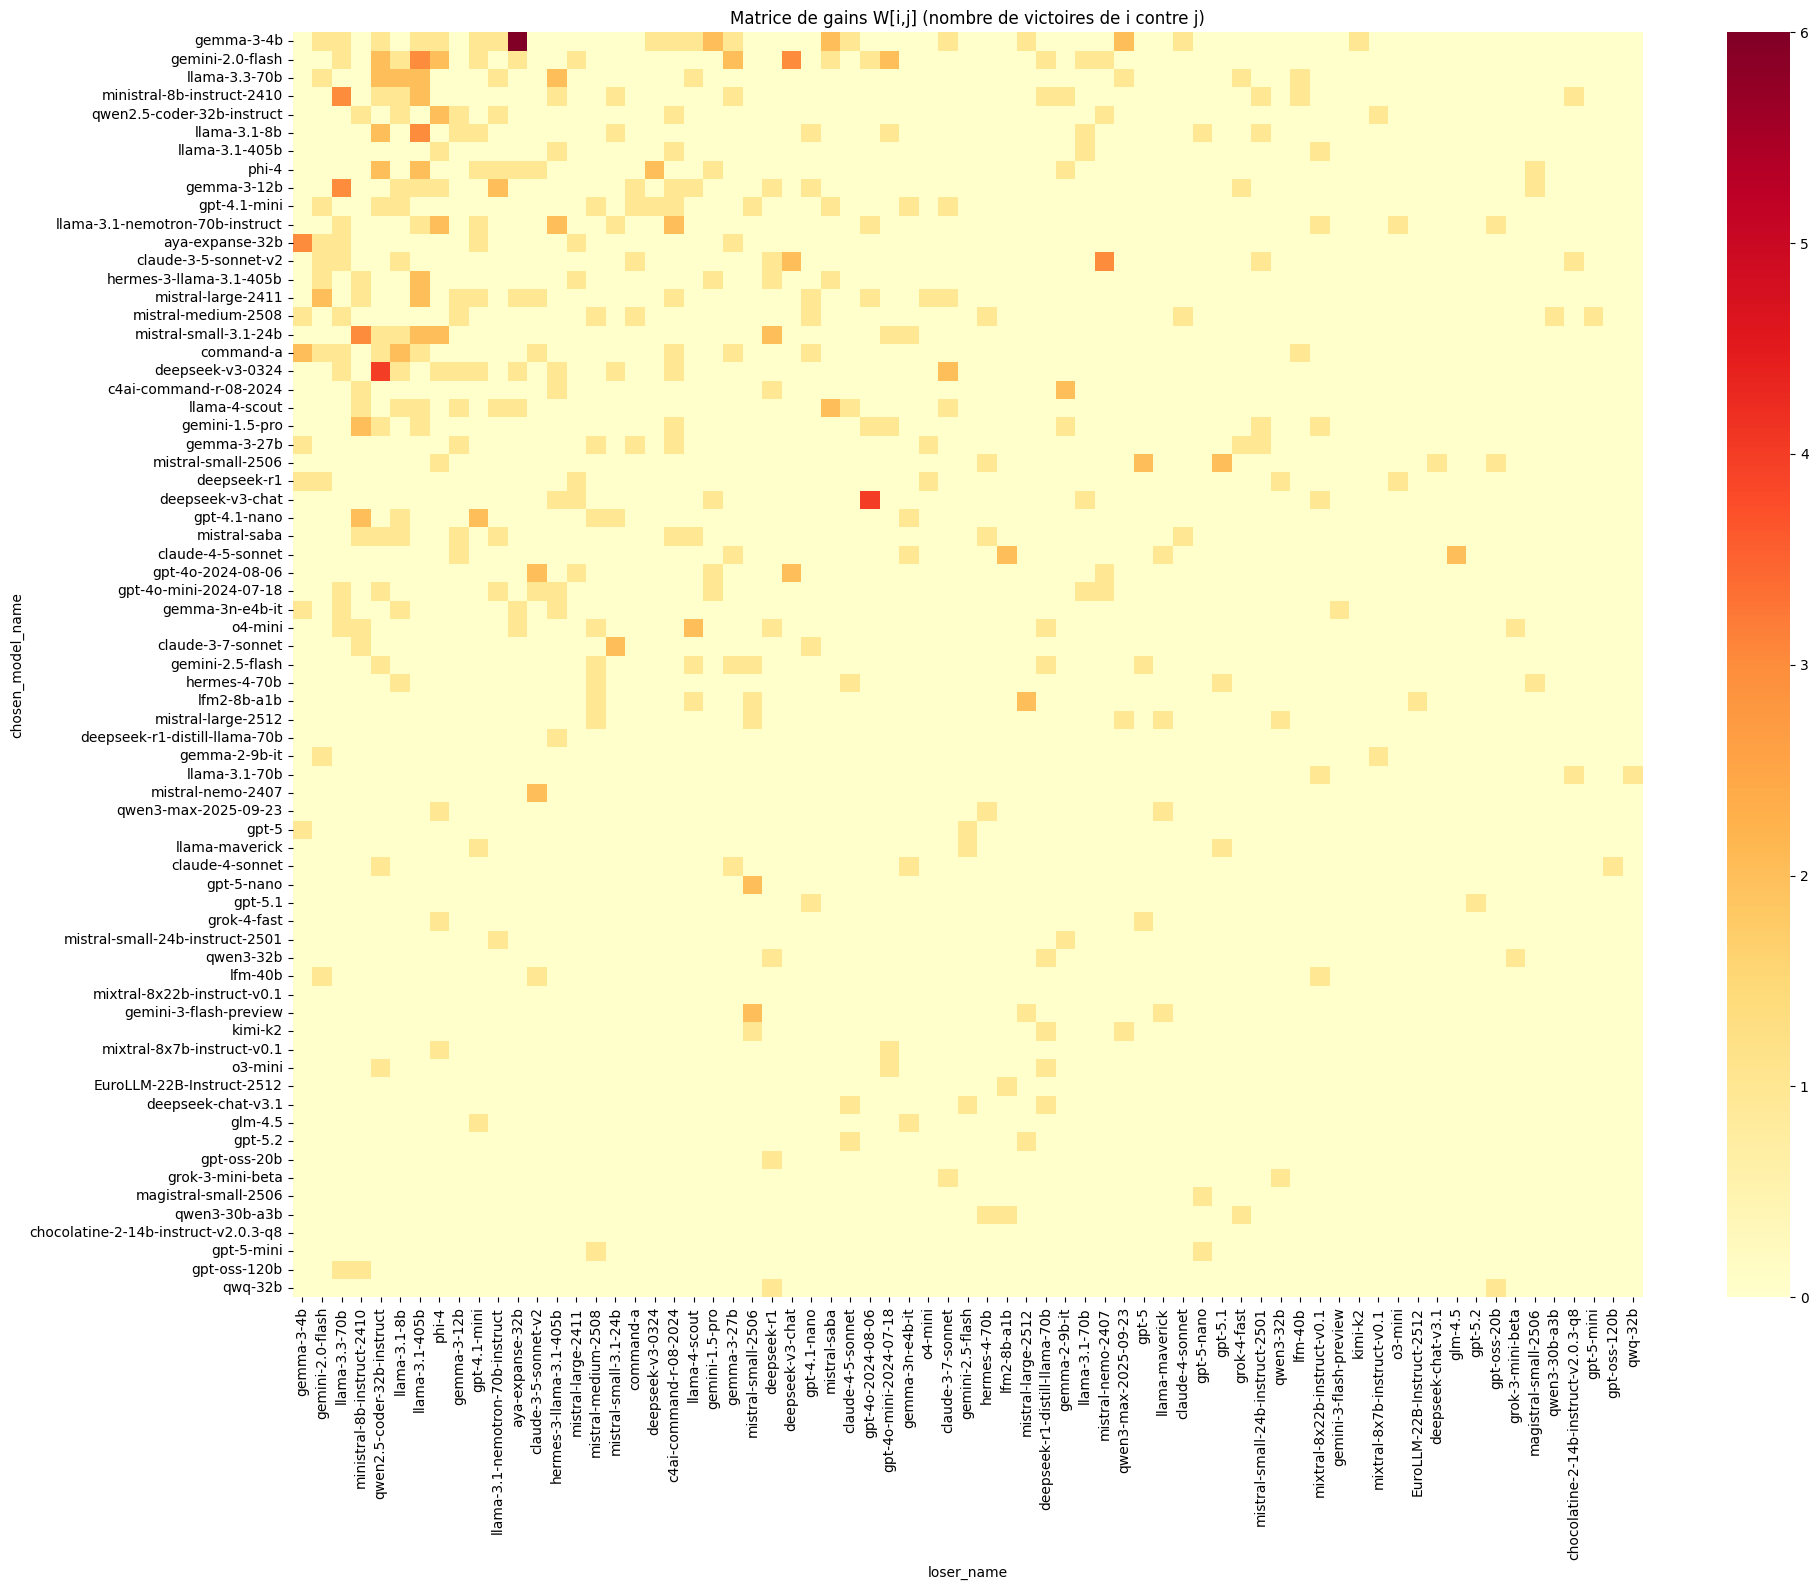

In [ ]:
plt.figure(figsize=(20, 16))
sns.heatmap(gain_matrix_filtered, cmap='YlOrRd', annot=False)
plt.title("Matrice de gains W[i,j] (nombre de victoires de i contre j)")
plt.tight_layout()
plt.show()

In [ ]:
beta_standard, ll_standard = bradley_terry_mle(gain_matrix_filtered)

ranking_standard = beta_standard.sort_values(ascending=False)
print("=== Classement Bradley-Terry STANDARD ===")
for i, (m, score) in enumerate(ranking_standard.items(), 1):
    print(f"{i:3d}. {m:45s} β = {score:.6f}")

C:\Users\rapha\AppData\Local\Temp\ipykernel_3804\4181995586.py:57: RuntimeWarning: divide by zero encountered in log
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
C:\Users\rapha\AppData\Local\Temp\ipykernel_3804\4181995586.py:57: RuntimeWarning: invalid value encountered in scalar multiply
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])


Convergence atteinte après 128 itérations
=== Classement Bradley-Terry STANDARD ===
  1. qwen3-30b-a3b                                 β = 0.058213
  2. gemini-3-flash-preview                        β = 0.057631
  3. deepseek-chat-v3.1                            β = 0.049299
  4. lfm2-8b-a1b                                   β = 0.044323
  5. EuroLLM-22B-Instruct-2512                     β = 0.044204
  6. gpt-5.2                                       β = 0.039861
  7. claude-4-5-sonnet                             β = 0.037340
  8. gpt-5-mini                                    β = 0.033733
  9. kimi-k2                                       β = 0.033603
 10. gemma-3-4b                                    β = 0.033375
 11. o4-mini                                       β = 0.029899
 12. gemini-2.5-flash                              β = 0.027684
 13. deepseek-v3-0324                              β = 0.025585
 14. mistral-medium-2508                           β = 0.025479
 15. command-a      

In [ ]:
lengths_a = df_bt_filtered[['model_a_name', 'conversation_a_length']].rename(
    columns={'model_a_name': 'model', 'conversation_a_length': 'length'}
)
lengths_b = df_bt_filtered[['model_b_name', 'conversation_b_length']].rename(
    columns={'model_b_name': 'model', 'conversation_b_length': 'length'}
)
all_lengths = pd.concat([lengths_a, lengths_b])
mean_lengths = all_lengths.groupby('model')['length'].mean()

print("=== Longueur moyenne des réponses par modèle (top 10) ===")
print(mean_lengths.sort_values(ascending=False).head(10))
print(f"\nMin : {mean_lengths.min():.0f}, Max : {mean_lengths.max():.0f}, Moyenne : {mean_lengths.mean():.0f}")

=== Longueur moyenne des réponses par modèle (top 10) ===
model
gpt-oss-120b        16168.333333
deepseek-v3-0324    10571.947368
grok-4-fast         10322.666667
o3-mini              9443.800000
gemma-3n-e4b-it      8355.083333
gpt-5.2              6910.666667
qwq-32b              6334.333333
gpt-5.1              6001.333333
grok-3-mini-beta     5737.250000
gemini-2.0-flash     5330.472222
Name: length, dtype: float64

Min : 529, Max : 16168, Moyenne : 3963


In [ ]:

gamma = model.coef_[0][0]
print(f"Coefficient γ du biais de longueur (issu de la régression logistique) : {gamma:.6f}")

beta_corrected, ll_corrected = bradley_terry_mle(gain_matrix_filtered, gamma=gamma, mean_lengths=mean_lengths)

ranking_corrected = beta_corrected.sort_values(ascending=False)
print("\n=== Classement Bradley-Terry CORRIGÉ ===")
for i, (m, score) in enumerate(ranking_corrected.items(), 1):
    print(f"{i:3d}. {m:45s} β_corrigé = {score:.6f}")

Coefficient γ du biais de longueur (issu de la régression logistique) : 0.000076
Convergence atteinte après 128 itérations


C:\Users\rapha\AppData\Local\Temp\ipykernel_3804\4181995586.py:57: RuntimeWarning: divide by zero encountered in log
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
C:\Users\rapha\AppData\Local\Temp\ipykernel_3804\4181995586.py:57: RuntimeWarning: invalid value encountered in scalar multiply
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])



=== Classement Bradley-Terry CORRIGÉ ===
  1. gemini-3-flash-preview                        β_corrigé = 0.063139
  2. qwen3-30b-a3b                                 β_corrigé = 0.062955
  3. lfm2-8b-a1b                                   β_corrigé = 0.050235
  4. EuroLLM-22B-Instruct-2512                     β_corrigé = 0.049870
  5. deepseek-chat-v3.1                            β_corrigé = 0.046074
  6. claude-4-5-sonnet                             β_corrigé = 0.043502
  7. kimi-k2                                       β_corrigé = 0.035369
  8. gpt-5-mini                                    β_corrigé = 0.034599
  9. o4-mini                                       β_corrigé = 0.032084
 10. gpt-5.2                                       β_corrigé = 0.031615
 11. gemma-3-4b                                    β_corrigé = 0.031573
 12. mistral-medium-2508                           β_corrigé = 0.026098
 13. command-a                                     β_corrigé = 0.025899
 14. gemini-2.5-flash 

c:\Users\rapha\OneDrive - De Vinci\centrale_s3\etude_de_cas\Measure_creativity_LLM\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
